# Cartpole TrajOpt and Learning Testing Notebook

In [1]:
# Import MuJoCo, MJX, and Brax
from datetime import datetime
import functools
import os
from typing import Any, Dict, Sequence, Tuple, Union
from brax import base
from brax import envs
from brax import math
from brax.base import Base, Motion, Transform
from brax.base import State as PipelineState
from brax.envs.base import Env, PipelineEnv, State
from brax.io import html, mjcf, model
from brax.mjx.base import State as MjxState
from brax.training.agents.ppo import networks as ppo_networks
from brax.training.agents.ppo import train as ppo
from brax.training.agents.sac import networks as sac_networks
from brax.training.agents.sac import train as sac
from etils import epath
from flax import struct
from flax.training import orbax_utils
from IPython.display import HTML, clear_output
import jax
from jax import numpy as jp
from matplotlib import pyplot as plt
import mediapy as media
from ml_collections import config_dict
import mujoco
from mujoco import mjx
import numpy as np
from orbax import checkpoint as ocp

# Import MuJoCo Playground
import mujoco_playground

## Cartpole Rollout Test

In [2]:
# Load the mujoco environment (can be from dm_control, robotic locomotion, or robotic manipulation)
env = mujoco_playground.registry.load('CartpoleBalance')

# Look at the configuration of the env
env_cfg = mujoco_playground.registry.get_default_config('CartpoleBalance')
env_cfg

action_repeat: 1
ctrl_dt: 0.01
episode_length: 1000
sim_dt: 0.01
vision: false
vision_config:
  enabled_geom_groups:
  - 0
  - 1
  - 2
  gpu_id: 0
  history: 3
  render_batch_size: 512
  render_height: 64
  render_width: 64
  use_rasterizer: false

In [3]:
# Let's do a simple rollout

# First, we must jit compile the reset and step functions
jit_reset = jax.jit(env.reset)
jit_step = jax.jit(env.step)

In [4]:
# Rollout a trajectory from the environment
state = jit_reset(rng=jax.random.PRNGKey(0))
rollout = [state]

# Generate state from actions for each time step based on a sine wave for the action
f = 0.5
for i in range(env_cfg.episode_length):
    action = []
    for j in range(env.action_size):
        action.append(
            jp.sin(
                state.data.time * 2 * jp.pi * f + j * 2 * jp.pi / env.action_size
            )
        )
    action = jp.array(action)
    state = jit_step(state, action)
    rollout.append(state)

frames = env.render(rollout)
media.show_video(frames, fps=1.0 / env.dt)

100%|██████████| 1001/1001 [00:00<00:00, 1133.17it/s]



This browser does not support the video tag.


In [5]:
# Notice how the env runs and lives on the device (GPU), this enables large-batch RL
state.obs.device
print(state.obs)

# Also make sure the default backend is the GPU and not CPU
print(jax.default_backend())

[ -1.950383    -0.79864496   0.6018025   -2.936009   -11.578764  ]
gpu


## Trajopt with Cartpole Environment
Here we try out a few trajectory optimization libraries written in JAX.

### trajax

In [ ]:
import trajax

def cartpole_cost(x, u, t):
    """Cost function for cartpole balancing task."""
    # NOTE: CartpoleBalance observation: [cart_pos, cos(pole_angle), sin(pole_angle), cart_vel, pole_angular_vel]
    # Not super sure this is the case, TODO: verify
    cart_pos = x[0]
    cos_pole = x[1]
    sin_pole = x[2] 
    cart_vel = x[3]
    pole_vel = x[4]
    
    # For balance task: penalize deviation from upright (cos=1, sin=0) and centered cart
    pos_cost = 10.0 * cart_pos**2
    angle_cost = 50.0 * ((cos_pole - 1.0)**2 + sin_pole**2)
    vel_cost = 1.0 * (cart_vel**2 + pole_vel**2)
    control_cost = 0.01 * u[0]**2
    
    return pos_cost + angle_cost + vel_cost + control_cost

def cartpole_dynamics(x, u, t):
    """Cartpole dynamics using the equations of motion derived from MuJoCo."""
    
    # TODO: This current thing is obviously incorrect as there's no equations of motion here.
    
    # Create a dummy state with the current observation
    # We'll use a template state and replace its observation
    dummy_state = jit_reset(rng=jax.random.PRNGKey(0))
    current_state = dummy_state.replace(obs=x)
    
    # Step the environment with the control input
    next_state = jit_step(current_state, u)
    
    # Return the next observation
    return next_state.obs

# Setup trajectory optimization for balance task (easier than swing-up)
T = 500
# Start near upright for balance task (small perturbation)
x0 = jp.array([0.1, 0.95, 0.31, 0.0, 0.0])  # slightly off-balance starting position

# Initialize with small random controls instead of zeros
rng = jax.random.PRNGKey(42)
U_init = jax.random.normal(rng, (T-1, 1)) * 0.1

print("Testing dynamics function...")
x_test = x0
u_test = jp.array([1.0])
x_next = cartpole_dynamics(x_test, u_test, 0.0)
print(f"Initial state: {x_test}")
print(f"Next state: {x_next}")

# Test cost function
cost_test = cartpole_cost(x_test, u_test, 0.0)
print(f"Cost at test state: {cost_test}")

# Solve using iLQR with more conservative parameters
print("\nSolving trajectory optimization...")
X_opt, U_opt, cost_opt, gradient, adjoints, lqr, iterations = trajax.optimizers.ilqr(
    cartpole_cost,
    cartpole_dynamics, 
    x0,
    U_init,
    maxiter=100
)

print(f"Final cost: {cost_opt:.4f}")
print(f"Iterations: {iterations}")

# Create rollout from optimized trajectory by stepping through environment
print("Creating optimized cartpole rollout...")
rollout_state = jit_reset(rng=jax.random.PRNGKey(0))
rollout_state = rollout_state.replace(obs=x0)  # Start from initial state
opt_rollout = [rollout_state]

# Step through optimized control sequence
for i in range(T-1):
    action = jp.array([U_opt[i, 0]])
    rollout_state = jit_step(rollout_state, action)
    opt_rollout.append(rollout_state)

# Render the optimized trajectory
print("Rendering optimized trajectory...")
frames = env.render(opt_rollout)
media.show_video(frames, fps=1.0 / env.dt)

Testing dynamics function...
Initial state: [0.1  0.95 0.31 0.   0.  ]
Next state: [ 0.06919418  0.99943876 -0.03349775  0.07313518 -0.16675086]
Cost at test state: 5.039999961853027

Solving trajectory optimization...
Cost at test state: 5.039999961853027

Solving trajectory optimization...
Final cost: 56.8278
Iterations: 2
Creating optimized cartpole rollout...
Final cost: 56.8278
Iterations: 2
Creating optimized cartpole rollout...
Rendering optimized trajectory...
Rendering optimized trajectory...


100%|██████████| 500/500 [00:00<00:00, 1342.94it/s]



This browser does not support the video tag.


### lqrax

In [ ]:
import lqrax
from lqrax import iLQR

# Define a CartpoleILQR class that extends LQRax's iLQR as in the example notebooks
class CartpoleILQR(iLQR):
    def __init__(self, dt, x_dim, u_dim, Q, R):
        super().__init__(dt, x_dim, u_dim, Q, R)
        # Store jit functions for use in dynamics
        self.jit_reset = jax.jit(env.reset)
        self.jit_step = jax.jit(env.step)
    
    def dyn(self, xt, ut):
        """Cartpole dynamics using the equations of motion derived from mujoco."""

        # TODO: This current thing is obviously incorrect as there's no equations of motion here.

        # Create a dummy state with the current observation
        dummy_state = self.jit_reset(rng=jax.random.PRNGKey(0))
        current_state = dummy_state.replace(obs=xt)
        
        # Step the environment with the control input
        next_state = self.jit_step(current_state, ut)
        
        # Return the next observation
        return next_state.obs

# Setup Q and R matrices for cartpole balancing
Q = jp.diag(jp.array([10.0, 50.0, 50.0, 1.0, 1.0]))  # [cart_pos, cos_pole, sin_pole, cart_vel, pole_vel]
R = jp.array([[0.01]])  # control cost

# Create the CartpoleILQR instance
cartpole_ilqr = CartpoleILQR(dt=env.dt, x_dim=5, u_dim=1, Q=Q, R=R)

# Test the dynamics function
print("Testing LQRax dynamics function...")
x_test = jp.array([0.1, 0.95, 0.31, 0.0, 0.0])
u_test = jp.array([1.0])
x_next = cartpole_ilqr.dyn(x_test, u_test)
print(f"Initial state: {x_test}")
print(f"Next state: {x_next}")

# Setup trajectory optimization
T = 100
x0 = jp.array([0.1, 0.95, 0.31, 0.0, 0.0])  # slightly off-balance starting position

# Initialize control trajectory with small random values
rng = jax.random.PRNGKey(42)
u_traj = jax.random.normal(rng, (T, 1)) * 0.1

# Define loss function components
def cartpole_loss(x_traj, u_traj):
    """Total loss for cartpole balancing."""
    # State cost: penalize deviation from upright (cos=1, sin=0) and centered cart
    pos_cost = 10.0 * jp.sum(x_traj[:, 0]**2)  # cart position
    angle_cost = 50.0 * jp.sum((x_traj[:, 1] - 1.0)**2 + x_traj[:, 2]**2)  # cos/sin pole angle
    vel_cost = 1.0 * jp.sum(x_traj[:, 3]**2 + x_traj[:, 4]**2)  # velocities
    control_cost = 0.01 * jp.sum(u_traj**2)  # control effort
    
    return pos_cost + angle_cost + vel_cost + control_cost

# Define linearization functions for the loss
@jax.jit
def linearize_loss(x_traj, u_traj):
    """Linearize the loss function to get a_traj and b_traj."""
    # For LQRax iLQR, we need gradients of loss w.r.t. state and control at each time step
    def loss_at_t(xt, ut):
        pos_cost = 10.0 * xt[0]**2
        angle_cost = 50.0 * ((xt[1] - 1.0)**2 + xt[2]**2) 
        vel_cost = 1.0 * (xt[3]**2 + xt[4]**2)
        control_cost = 0.01 * ut[0]**2
        return pos_cost + angle_cost + vel_cost + control_cost
    
    # Compute gradients
    dldx = jax.grad(loss_at_t, argnums=0)
    dldu = jax.grad(loss_at_t, argnums=1)
    
    # Apply to all time steps
    a_traj = jax.vmap(dldx, in_axes=(0, 0))(x_traj, u_traj)
    b_traj = jax.vmap(dldu, in_axes=(0, 0))(x_traj, u_traj)
    
    return a_traj, b_traj

# iLQR optimization loop
num_iters = 20
print(f"\nRunning LQRax iLQR optimization for {num_iters} iterations...")

for iteration in range(num_iters):
    # Linearize dynamics around current trajectory
    x_traj, A_traj, B_traj = cartpole_ilqr.linearize_dyn(x0, u_traj)
    
    # Linearize loss function
    a_traj, b_traj = linearize_loss(x_traj, u_traj)
    
    # Solve iLQR subproblem to get descent direction
    v_traj, z_traj = cartpole_ilqr.solve(A_traj, B_traj, a_traj, b_traj)
    
    # Line search for step size
    step_sizes = jp.array([0.001, 0.01, 0.1, 0.5, 1.0])
    best_loss = jp.inf
    best_step = 0.0
    
    for step in step_sizes:
        u_new = u_traj + step * v_traj
        x_new = cartpole_ilqr.traj_sim(x0, u_new)
        loss_val = cartpole_loss(x_new, u_new)
        if loss_val < best_loss:
            best_loss = loss_val
            best_step = step
    
    # Update control trajectory
    u_traj = u_traj + best_step * v_traj
    
    # Print progress
    if iteration % 5 == 0 or iteration == num_iters - 1:
        final_x_traj = cartpole_ilqr.traj_sim(x0, u_traj)
        loss_val = cartpole_loss(final_x_traj, u_traj)
        print(f"Iteration {iteration:2d}: loss = {loss_val:.4f}, step_size = {best_step:.3f}")

# Final results
print("\nOptimization complete!")
final_x_traj = cartpole_ilqr.traj_sim(x0, u_traj)
final_loss = cartpole_loss(final_x_traj, u_traj)

print(f"Final loss: {final_loss:.4f}")
print(f"Control variation - min: {jp.min(u_traj):.6f}, max: {jp.max(u_traj):.6f}, std: {jp.std(u_traj):.6f}")

# Convert cos/sin back to angle for summary
pole_angles = jp.arctan2(final_x_traj[:, 2], final_x_traj[:, 1])
print(f"Initial pole angle: {pole_angles[0] * 180/jp.pi:.1f}°")
print(f"Final pole angle: {pole_angles[-1] * 180/jp.pi:.1f}°")
print(f"Max cart displacement: {jp.max(jp.abs(final_x_traj[:, 0])):.3f}m")

# Create and render rollout from optimized trajectory
print("\nCreating optimized cartpole rollout...")
rollout_state = jit_reset(rng=jax.random.PRNGKey(0))
rollout_state = rollout_state.replace(obs=x0)
opt_rollout = [rollout_state]

for i in range(T):
    action = jp.array([u_traj[i, 0]])
    rollout_state = jit_step(rollout_state, action)
    opt_rollout.append(rollout_state)

print("Rendering optimized trajectory...")
frames = env.render(opt_rollout)
media.show_video(frames, fps=1.0 / env.dt)

Testing LQRax dynamics function...
Initial state: [0.1  0.95 0.31 0.   0.  ]
Next state: [ 0.06919418  0.99943876 -0.03349775  0.07313518 -0.16675086]

Running LQRax iLQR optimization for 20 iterations...
Iteration  0: loss = 1898.4506, step_size = 0.500
Iteration  0: loss = 1898.4506, step_size = 0.500
Iteration  5: loss = 1898.4504, step_size = 0.001
Iteration  5: loss = 1898.4504, step_size = 0.001
Iteration 10: loss = 1898.4504, step_size = 0.001
Iteration 10: loss = 1898.4504, step_size = 0.001
Iteration 15: loss = 1898.4504, step_size = 0.001
Iteration 15: loss = 1898.4504, step_size = 0.001
Iteration 19: loss = 1898.4504, step_size = 0.001

Optimization complete!
Final loss: 1898.4504
Control variation - min: -0.095413, max: -0.001368, std: 0.026273
Iteration 19: loss = 1898.4504, step_size = 0.001

Optimization complete!
Final loss: 1898.4504
Control variation - min: -0.095413, max: -0.001368, std: 0.026273
Initial pole angle: 17.9°
Final pole angle: 8.1°
Max cart displacement:

100%|██████████| 101/101 [00:00<00:00, 1074.04it/s]



This browser does not support the video tag.


## RL with Cartpole Environment

Here we compare the Brax implementations and SBX implementations

### Brax

In [8]:
from mujoco_playground.config import dm_control_suite_params
ppo_params = dm_control_suite_params.brax_ppo_config('CartpoleBalance')
sac_params = dm_control_suite_params.brax_sac_config('CartpoleBalance')
ppo_params

action_repeat: 1
batch_size: 1024
discounting: 0.995
entropy_cost: 0.01
episode_length: 1000
learning_rate: 0.001
normalize_observations: true
num_envs: 2048
num_evals: 10
num_minibatches: 32
num_timesteps: 60000000
num_updates_per_batch: 16
reward_scaling: 10.0
unroll_length: 30

#### Brax PPO

In [9]:
x_data, y_data, y_dataerr = [], [], []
times = [datetime.now()]


def progress(num_steps, metrics):
  clear_output(wait=True)

  times.append(datetime.now())
  x_data.append(num_steps)
  y_data.append(metrics["eval/episode_reward"])
  y_dataerr.append(metrics["eval/episode_reward_std"])

  plt.xlim([0, ppo_params["num_timesteps"] * 1.25])
  plt.ylim([0, 1100])
  plt.xlabel("# environment steps")
  plt.ylabel("reward per episode")
  plt.title(f"y={y_data[-1]:.3f}")
  plt.errorbar(x_data, y_data, yerr=y_dataerr, color="blue")

  display(plt.gcf())

ppo_training_params = dict(ppo_params)
network_factory = ppo_networks.make_ppo_networks
if "network_factory" in ppo_params:
  del ppo_training_params["network_factory"]
  network_factory = functools.partial(
      ppo_networks.make_ppo_networks,
      **ppo_params.network_factory
  )

train_fn = functools.partial(
    ppo.train, **dict(ppo_training_params),
    network_factory=network_factory,
    progress_fn=progress
)

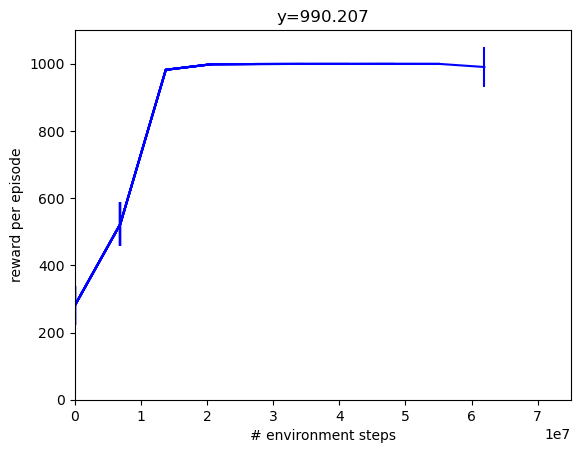

time to jit: 0:00:10.352978
time to train: 0:00:58.249348


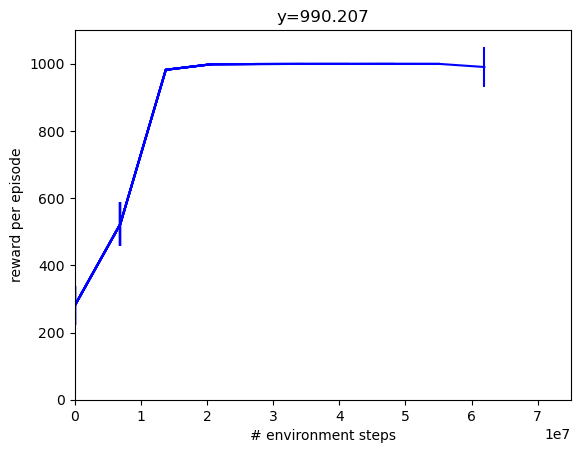

In [10]:
from mujoco_playground import wrapper

make_inference_fn, params, metrics = train_fn(
    environment=env,
    wrap_env_fn=wrapper.wrap_for_brax_training,
)
print(f"time to jit: {times[1] - times[0]}")
print(f"time to train: {times[-1] - times[1]}")

In [11]:
jit_reset = jax.jit(env.reset)
jit_step = jax.jit(env.step)
jit_inference_fn = jax.jit(make_inference_fn(params, deterministic=True))

In [12]:
rng = jax.random.PRNGKey(42)
rollout = []
n_episodes = 1

for _ in range(n_episodes):
  state = jit_reset(rng)
  rollout.append(state)
  for i in range(env_cfg.episode_length):
    act_rng, rng = jax.random.split(rng)
    ctrl, _ = jit_inference_fn(state.obs, act_rng)
    state = jit_step(state, ctrl)
    rollout.append(state)

render_every = 1
frames = env.render(rollout[::render_every])
rewards = [s.reward for s in rollout]
media.show_video(frames, fps=1.0 / env.dt / render_every)

100%|██████████| 1001/1001 [00:00<00:00, 1081.39it/s]



This browser does not support the video tag.


#### Brax SAC

In [13]:
x_data, y_data, y_dataerr = [], [], []
times = [datetime.now()]


def progress(num_steps, metrics):
  clear_output(wait=True)

  times.append(datetime.now())
  x_data.append(num_steps)
  y_data.append(metrics["eval/episode_reward"])
  y_dataerr.append(metrics["eval/episode_reward_std"])

  plt.xlim([0, sac_params["num_timesteps"] * 1.25])
  plt.ylim([0, 1100])
  plt.xlabel("# environment steps")
  plt.ylabel("reward per episode")
  plt.title(f"y={y_data[-1]:.3f}")
  plt.errorbar(x_data, y_data, yerr=y_dataerr, color="blue")

  display(plt.gcf())

sac_training_params = dict(sac_params)
network_factory = sac_networks.make_sac_networks
if "network_factory" in sac_params:
  del sac_training_params["network_factory"]
  network_factory = functools.partial(
      sac_networks.make_sac_networks,
      **sac_params.network_factory
  )

train_fn = functools.partial(
    sac.train, **dict(sac_training_params),
    network_factory=network_factory,
    progress_fn=progress
)

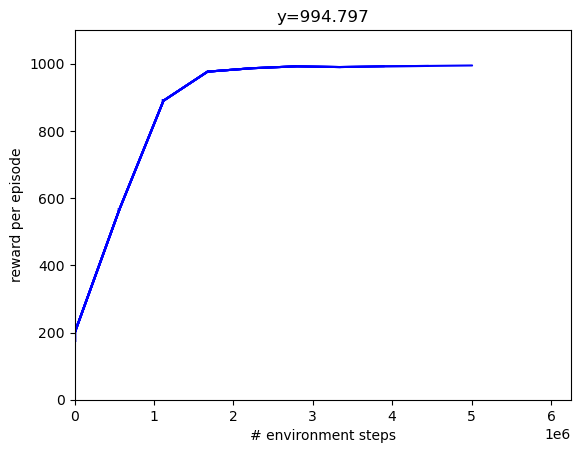

time to jit: 0:00:08.741344
time to train: 0:01:31.618712


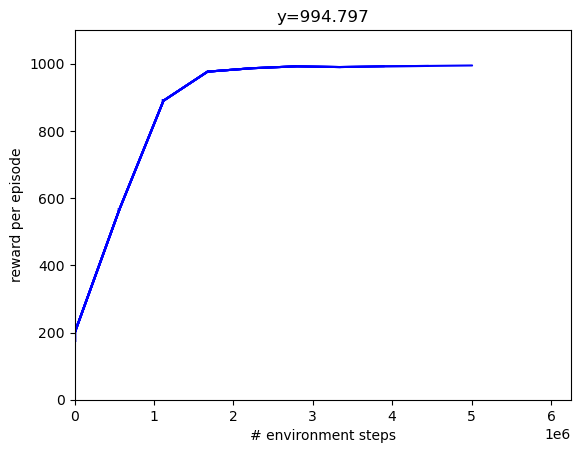

In [14]:
make_inference_fn, params, metrics = train_fn(
    environment=env,
    wrap_env_fn=wrapper.wrap_for_brax_training,
)
print(f"time to jit: {times[1] - times[0]}")
print(f"time to train: {times[-1] - times[1]}")

In [15]:
jit_reset = jax.jit(env.reset)
jit_step = jax.jit(env.step)
jit_inference_fn = jax.jit(make_inference_fn(params, deterministic=True))

In [16]:
rng = jax.random.PRNGKey(0)
rollout = []
n_episodes = 1

for _ in range(n_episodes):
  state = jit_reset(rng)
  rollout.append(state)
  for i in range(env_cfg.episode_length):
    act_rng, rng = jax.random.split(rng)
    ctrl, _ = jit_inference_fn(state.obs, act_rng)
    state = jit_step(state, ctrl)
    rollout.append(state)

render_every = 1
frames = env.render(rollout[::render_every])
rewards = [s.reward for s in rollout]
media.show_video(frames, fps=1.0 / env.dt / render_every)

100%|██████████| 1001/1001 [00:00<00:00, 1225.20it/s]



This browser does not support the video tag.
